# Tutorial on how to use Directional DIC to measuere displacement from videos
Unidirectional translation identification as introduced in:
Masmeijer T., Habtour E., Zaletelj, K., & Slavič, J., (2024). **Directional DIC method with automatic feature selection**. *MSSP*.
"https://doi.org/10.1016/j.ymssp.2024.112080".

The implementation is based on the Lucas-Kanade method using least-squares iterative optimization with the Zero Normalized
Cross Correlation optimization criterion.

In [1]:
import os
import sys
sys.path.insert(0, os.path.realpath('__file__'))

import numpy as np
import matplotlib.pyplot as plt
import pickle
import pyidi

Load the video

In [2]:
filename = '../data/data_synthetic.cih'
video = pyidi.VideoReader(filename)

In [3]:
print(f"N images: {video.N}")
print(f"Image height: {video.image_height}")
print(f"Image width: {video.image_width}")

N images: 101
Image height: 128
Image width: 256


In [4]:
%matplotlib qt
import matplotlib.animation as animation

def play_video(frame_range = None, interval=30, points = None, ij_counter = (0.65, 0.05)):
    
    """
    Plays the video from the given video object.
    Args:
        frame_range (range object): The range of frames to play.
        interval (int): The interval between frames in milliseconds.
        points (ndarray): Optional tracked points to plot on the video.
        ij_counter (tuple): The position of the frame counter.
    """
    if frame_range is None:
        frame_range = range(0, video.N)
    fig, ax = plt.subplots()
    im = ax.imshow(video.get_frame(frame_range[0]), cmap='gray')
    text = ax.text(ij_counter[0], ij_counter[1], '', transform=ax.transAxes, color='black', ha='right', va='bottom')

    if points is not None:
        pts = ax.plot(points[:,0,1], points[:,0,0], 'r.')

    def update(i):
        im.set_data(video.get_frame(i))
        text.set_text(f'Frame {i}')
        if points is not None:
            pts[0].set_data(points[:,i,1], points[:,i,0])
        return im, text

    ani = animation.FuncAnimation(fig, update, frames=frame_range, interval=interval)
    plt.show()
    return ani

ani = play_video(range(1, video.N))

## `Lucas Kanade` method as a reference

In [5]:
tol = 1e-8
roi_size = (5,5)
idi_lk = pyidi.LucasKanade(video)
idi_lk.configure(reference_image = (0,100), resume_analysis = False, tol=tol, roi_size=roi_size)
reference_image = idi_lk._set_reference_image(video, idi_lk.reference_image)

# Select the highest gradient points
Gi, Gj = np.gradient(reference_image)
G = np.sqrt(Gi**2 + Gj**2)
highest_points = np.argpartition(G.flatten(), -10)[-10:]
arguments = np.unravel_index(highest_points, G.shape)

Visualize the selected points

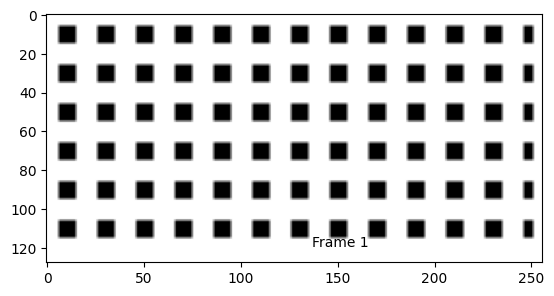

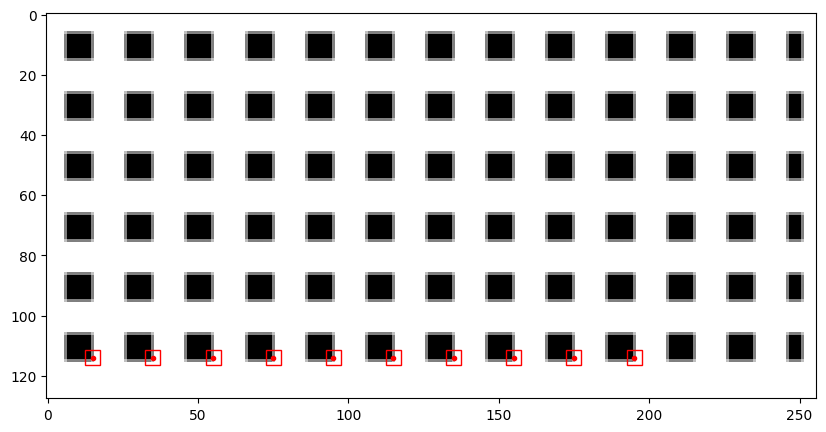

In [6]:
%matplotlib inline
points2d = np.array(arguments).T
idi_lk.set_points(points2d)
idi_lk.show_points()

Compoute displacements

In [7]:
displacementes_2d = idi_lk.get_displacements(processes=1, autosave=False)

Output()

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.01 s


Time to complete: 2.5 s


## `Directional - Lucas Kanade` method

In [8]:
idi_dlk = pyidi.DirectionalLucasKanade(video)

In [22]:
rgb_ij, np.flip(rgb_ij, axis=1)

(array([[ 0.        ,  0.        ],
        [ 0.        ,  0.0596008 ],
        [ 0.        ,  0.1168255 ],
        [ 0.        ,  0.16939274],
        [ 0.        ,  0.21520683],
        [ 0.        ,  0.2524413 ],
        [ 0.        ,  0.27961173],
        [ 0.        ,  0.29563492],
        [ 0.        ,  0.29987208],
        [ 0.        ,  0.29215429],
        [ 0.        ,  0.27278923],
        [ 0.        ,  0.24254892],
        [ 0.        ,  0.20263895],
        [ 0.        ,  0.15465041],
        [ 0.        ,  0.10049645],
        [ 0.        ,  0.042336  ],
        [-0.        , -0.01751224],
        [-0.        , -0.07666233],
        [-0.        , -0.13275613],
        [-0.        , -0.18355737],
        [-0.        , -0.22704075],
        [-0.        , -0.26147273],
        [-0.        , -0.28548062],
        [-0.        , -0.2981073 ],
        [-0.        , -0.29884938],
        [-0.        , -0.28767728],
        [-0.        , -0.2650364 ],
        [-0.        , -0.231

Define the direction of motion

In [23]:
tol = 1e-8
roi_size = (5,5)

dij = (0., 0.5) # set the direction of motion
# dij = np.array([[0.0, 0.5], 
#                 [0.1, 0.5],
#                 [0.2, 0.5], 
#                 [0.3, 0.5], 
#                 [0.4, 0.5], 
#                 [0.5, 0.5], 
#                 [0.6, 0.5], 
#                 [0.7, 0.5], 
#                 [0.8, 0.5], 
#                 [0.9, 0.5], ])
idi_dlk.configure(reference_image = (0,100), dij=dij, resume_analysis = False, tol=tol,roi_size=roi_size, pad=(4,4))
rgb_ij = np.outer(0.3*np.array(idi_dlk.dij),np.sin(0.2*np.arange(idi_dlk.N_time_points))).T
rgb_ij += np.flip(rgb_ij, axis=1)*0.1


reference_image = idi_dlk._set_reference_image(video, idi_dlk.reference_image)
Gi, Gj = np.gradient(reference_image)
G = np.sqrt(Gi**2 + Gj**2)
highest_points = np.argpartition(G.flatten(), -10)[-10:]
arguments = np.unravel_index(highest_points, G.shape)

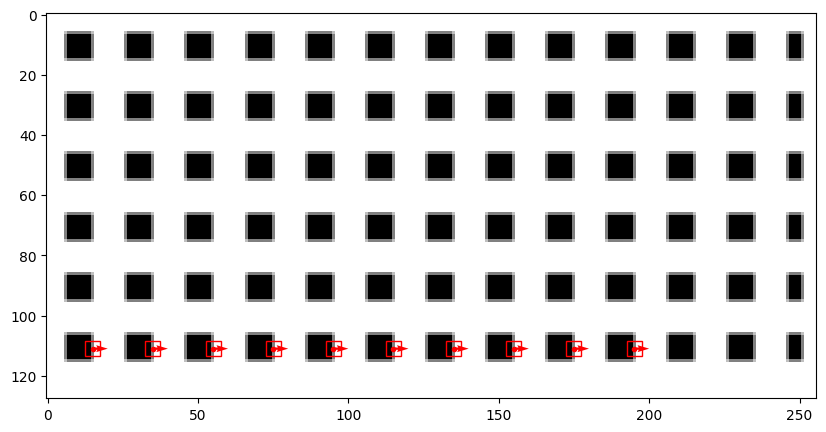

array([0., 1.])

In [24]:
%matplotlib inline
points1d = np.array(arguments).T
idi_dlk.set_points(points1d - np.array([3,0]))
idi_dlk.set_rigid_body_motion(rgb_ij)
idi_dlk.show_points()
idi_dlk.dij

Compute displacements

In [11]:
# idi_dlk.clear_temp_files()

In [30]:
displacements = idi_dlk.get_displacements(processes=1, autosave=False)

--- Starting new analysis ---
 


Output()

Interpolating the reference image...
...done in 0.01 s


Time to complete: 3 min, 0.0 s


In [26]:
import copy
idi_dlk2 = copy.deepcopy(idi_dlk)
idi_dlk2.set_rigid_body_motion(None)
displacements2 = idi_dlk2.get_displacements(processes=1, autosave=False)

Output()

--- Starting new analysis ---
 
Interpolating the reference image...
...done in 0.01 s


Time to complete: 2.1 s


## Comparison

An existing analysis can also be loaded without computation and setting the arguments.

In [29]:
%matplotlib qt
fig, ax = plt.subplots()
# ax.plot(displacements[0,:,0])
ax.plot(rgb_ij[:,0], label = 'rigid body motion')
ax.plot(displacements[0,:,0] + rgb_ij[:,0], label = 'rgb accounted')
ax.plot(displacements2[0,:,0], label = 'original')

ax.plot(displacementes_2d[0,:,0])
